In [3]:
import wandb
from glob import glob
import pandas
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Results for PD Control and Baseline

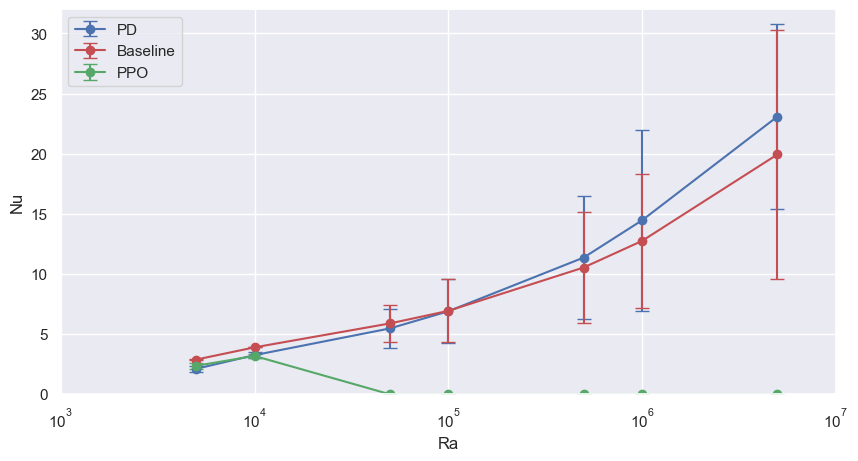

In [11]:
mean = {"baseline": [], "pd": [], "ppo": []}
std = {"baseline": [], "pd": [], "ppo": []}
ra = [5000, 10000, 50000, 100000, 500000, 1000000, 5000000]

for method in ["baseline", "pd", "ppo"]:
    for r in ra:
        path = f"res/{method}_ra{r}.csv"
        try:
            df = pandas.read_csv(path)
            mean[method].append(df["nusselt"].mean())
            std[method].append(df["nusselt"].std())
        except:
            mean[method].append(0)
            std[method].append(0)
        
# plot
plt.figure(figsize=(10, 5))
sns.set_theme()

# x axis
plt.xlim(1000, 10000000)
plt.xticks(ticks=[1000, 10000, 100000, 1000000, 10000000], labels=["$10^3$", "$10^4$","$10^5$","$10^6$", "$10^7$"])
plt.xlabel("Ra")
plt.xscale("log")

# y axis
plt.ylim(0, 32)
plt.ylabel("Nu")

# plot data
plt.errorbar(ra, mean["pd"], std["pd"], linestyle="-", marker='o', color='b', capsize=5, label="PD")
plt.errorbar(ra, mean["baseline"], std["baseline"], linestyle="-", marker='o', color='r', capsize=5, label="Baseline")
plt.errorbar(ra, mean["ppo"], std["ppo"], linestyle="-", marker='o', color='g', capsize=5, label="PPO")


plt.legend()
plt.show()